Upload your Titanic CSV file


Saving train.csv to train (1).csv

Dataset Loaded Successfully
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123    

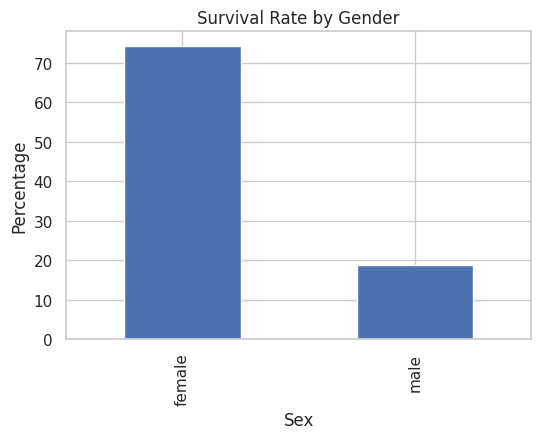


Survival Rate by Passenger Class
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


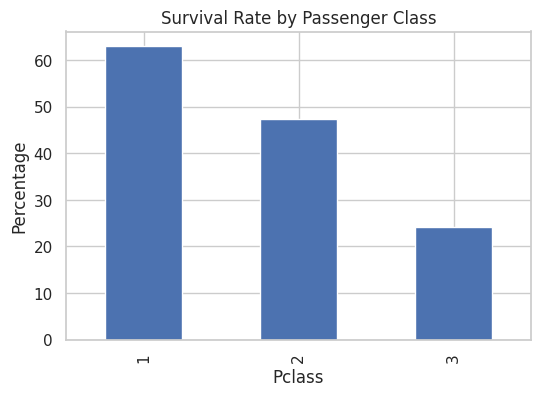

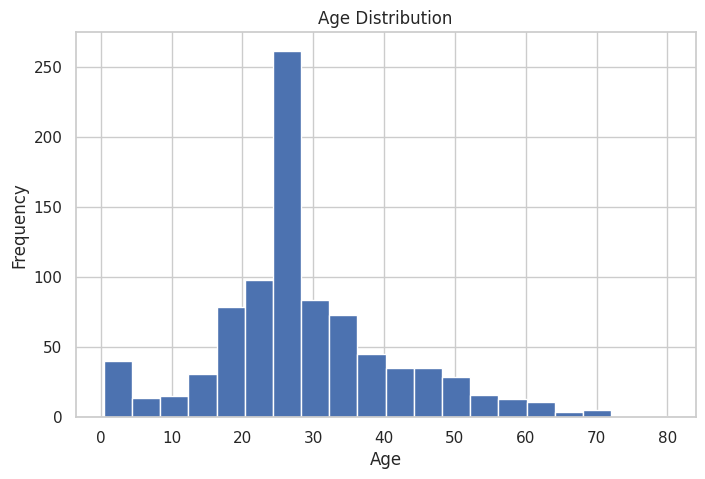

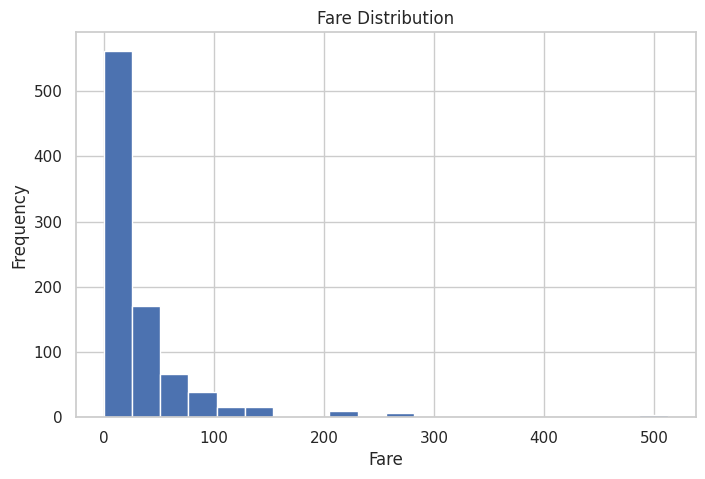

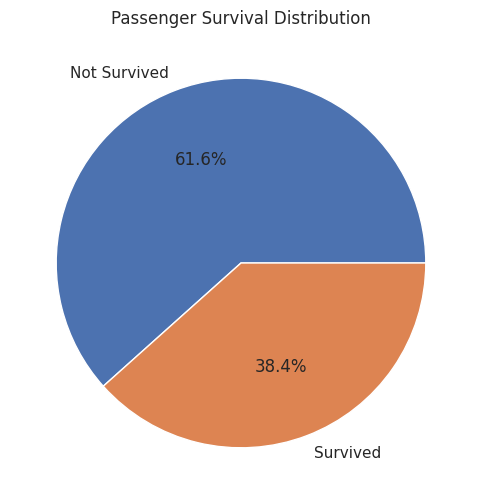

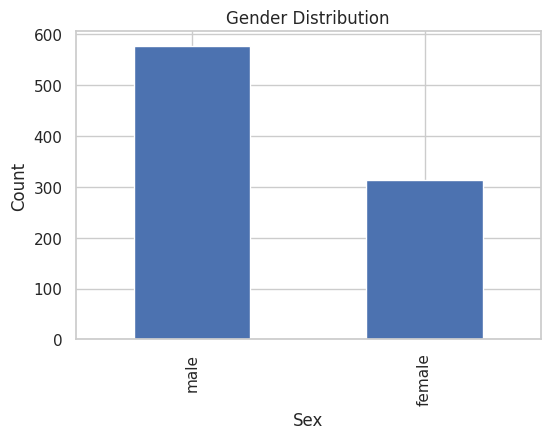

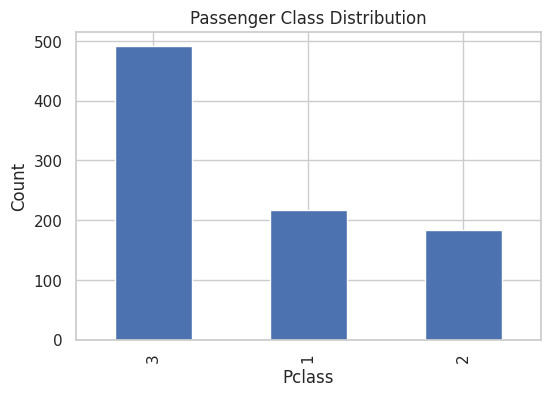

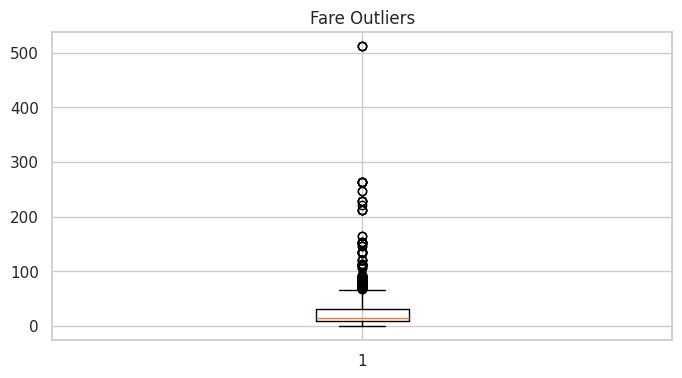


Average Fare By Class
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


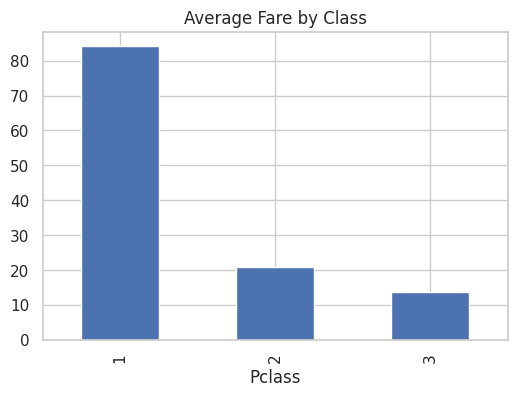


Survival by Age Group
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


/tmp/ipykernel_19969/2140600966.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived']


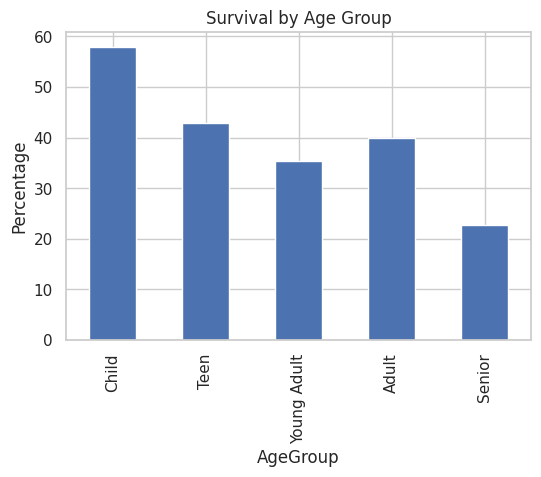

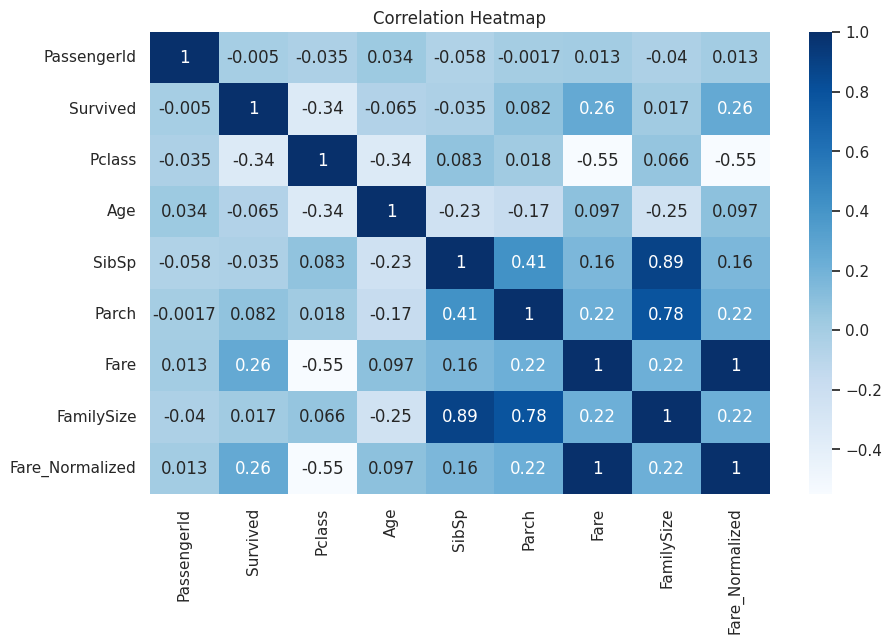


Top 10 Highest Fare Passengers
                                      Name      Fare  Pclass
258                       Ward, Miss. Anna  512.3292       1
679     Cardeza, Mr. Thomas Drake Martinez  512.3292       1
737                 Lesurer, Mr. Gustave J  512.3292       1
27          Fortune, Mr. Charles Alexander  263.0000       1
88              Fortune, Miss. Mabel Helen  263.0000       1
341         Fortune, Miss. Alice Elizabeth  263.0000       1
438                      Fortune, Mr. Mark  263.0000       1
311             Ryerson, Miss. Emily Borie  262.3750       1
742  Ryerson, Miss. Susan Parker "Suzette"  262.3750       1
118               Baxter, Mr. Quigg Edmond  247.5208       1

========== BUSINESS INSIGHTS ==========
1. Missing values were detected and cleaned.
2. Duplicate records were checked and removed.
3. FamilySize feature was created.
4. Age groups were generated.
5. Fare values were normalized.
6. Fare outliers were detected.
7. Female passengers showed higher 

In [4]:
# ============================================
# TITANIC DATA ANALYSIS PROJECT
# 15+ Transformations & Insights
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload CSV File
from google.colab import files

print("Upload your Titanic CSV file")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nDataset Loaded Successfully")
print(df.head())

# ============================================
# 1. DATASET OVERVIEW
# ============================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nStatistics:")
print(df.describe())

# ============================================
# 2. CHECK MISSING VALUES
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# 3. HANDLE MISSING VALUES
# ============================================

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ============================================
# 4. REMOVE DUPLICATES
# ============================================

duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)

df = df.drop_duplicates()

# ============================================
# 5. CREATE FAMILY SIZE FEATURE
# ============================================

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("\nFamilySize Feature Added")

# ============================================
# 6. CREATE AGE GROUPS
# ============================================

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

print("\nAge Groups:")
print(df['AgeGroup'].value_counts())

# ============================================
# 7. NORMALIZATION
# ============================================

df['Fare_Normalized'] = (
    (df['Fare'] - df['Fare'].min()) /
    (df['Fare'].max() - df['Fare'].min())
)

print("\nFare Normalized")

# ============================================
# 8. OUTLIER DETECTION
# ============================================

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Fare'] < lower) |
    (df['Fare'] > upper)
]

print("\nNumber of Fare Outliers:", len(outliers))

# ============================================
# 9. SURVIVAL RATE BY GENDER
# ============================================

survival_gender = (
    df.groupby('Sex')['Survived']
    .mean() * 100
)

print("\nSurvival Rate by Gender")
print(survival_gender)

plt.figure(figsize=(6,4))
survival_gender.plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.ylabel("Percentage")
plt.show()

# ============================================
# 10. SURVIVAL RATE BY CLASS
# ============================================

survival_class = (
    df.groupby('Pclass')['Survived']
    .mean() * 100
)

print("\nSurvival Rate by Passenger Class")
print(survival_class)

plt.figure(figsize=(6,4))
survival_class.plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Percentage")
plt.show()

# ============================================
# 11. AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# ============================================
# 12. FARE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))
plt.hist(df['Fare'], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

# ============================================
# 13. SURVIVAL PIE CHART
# ============================================

survival_counts = df['Survived'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    survival_counts,
    labels=['Not Survived','Survived'],
    autopct='%1.1f%%'
)

plt.title("Passenger Survival Distribution")
plt.show()

# ============================================
# 14. GENDER DISTRIBUTION
# ============================================

plt.figure(figsize=(6,4))

df['Sex'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.ylabel("Count")

plt.show()

# ============================================
# 15. CLASS DISTRIBUTION
# ============================================

plt.figure(figsize=(6,4))

df['Pclass'].value_counts().plot(kind='bar')

plt.title("Passenger Class Distribution")
plt.ylabel("Count")

plt.show()

# ============================================
# 16. BOXPLOT FOR OUTLIERS
# ============================================

plt.figure(figsize=(8,4))

plt.boxplot(df['Fare'])

plt.title("Fare Outliers")

plt.show()

# ============================================
# 17. AVERAGE FARE BY CLASS
# ============================================

avg_fare = df.groupby('Pclass')['Fare'].mean()

print("\nAverage Fare By Class")
print(avg_fare)

plt.figure(figsize=(6,4))

avg_fare.plot(kind='bar')

plt.title("Average Fare by Class")

plt.show()

# ============================================
# 18. AGE GROUP SURVIVAL
# ============================================

age_survival = (
    df.groupby('AgeGroup')['Survived']
    .mean() * 100
)

print("\nSurvival by Age Group")
print(age_survival)

plt.figure(figsize=(6,4))

age_survival.plot(kind='bar')

plt.title("Survival by Age Group")
plt.ylabel("Percentage")

plt.show()

# ============================================
# 19. CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================
# 20. TOP 10 HIGHEST FARES
# ============================================

print("\nTop 10 Highest Fare Passengers")

print(
    df.nlargest(10,'Fare')
    [['Name','Fare','Pclass']]
)

# ============================================
# FINAL INSIGHTS
# ============================================

print("\n========== BUSINESS INSIGHTS ==========")

print("1. Missing values were detected and cleaned.")
print("2. Duplicate records were checked and removed.")
print("3. FamilySize feature was created.")
print("4. Age groups were generated.")
print("5. Fare values were normalized.")
print("6. Fare outliers were detected.")
print("7. Female passengers showed higher survival rates.")
print("8. First-class passengers survived more often.")
print("9. Passenger class strongly influenced fare.")
print("10. Most passengers belonged to the Young Adult category.")
print("11. Correlation analysis identified feature relationships.")
print("12. Multiple visualizations were created for stakeholders.")

print("\nPROJECT COMPLETED SUCCESSFULLY")